# Notebook for practical exercises | Week #5 Lesson #2

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Explainable AI*.

Using a pretrained [NIH ChestX-ray-14](https://nihcc.app.box.com/v/ChestXray-NIHCC) dataset, for classification, generate and compare three types of explanations on a set of 10 images (5 pathology-positive, 5 pathology-negative):
1. Produce Grad-CAM heatmaps for each image.
2. Produce Score-CAM heatmaps for each image.
2. Produce Grad-CAM ++ heatmaps for each image.
3. Produce LIME superpixel explanations for each image.



## Dataset

[NIH ChestX-ray-14](https://nihcc.app.box.com/v/ChestXray-NIHCC) dataset comprises 112,120 frontal-view X-ray images of 30,805 unique patients with the text-mined fourteen disease image labels (where each image can have multi-labels), mined from the associated radiological reports using natural language processing.
Fourteen common thoracic pathologies include Atelectasis, Consolidation, Infiltration, Pneumothorax, Edema, Emphysema, Fibrosis, Effusion, Pneumonia, Pleural_thickening, Cardiomegaly, Nodule, Mass and Hernia.

It contains:
1. 112,120 frontal-view chest X-ray PNG images in 1024*1024 resolution (under images folder)
2. Meta data for all images (Data_Entry_2017.csv): Image Index, Finding Labels, Follow-up #, Patient ID, Patient Age, Patient Gender, View Position, Original Image Size and Original Image Pixel Spacing.
3. Bounding boxes for ~1000 images (BBox_List_2017.csv): Image Index, Finding Label, Bbox[x, y, w, h]. [x y] are coordinates of each box's topleft corner. [w h] represent the width and height of each box.
4. Two data split files (train_val_list.txt and test_list.txt) are provided. Images in the ChestX-ray dataset are divided into these two sets on the patient level. All studies from the same patient will only appear in either training/validation or testing set.

Here, we will use a subsample of this dataset along with pretrained models from the last week.

In [1]:
!pip install "numpy<2.3" -q
!pip install lime -q
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import osgeo_utils
import sys
import os
from glob import glob
import warnings
!pip install pydicom SimpleITK grad-cam -q

warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import SimpleITK as sitk
sitk.ProcessObject.SetGlobalWarningDisplay(False)
#
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

from PIL import Image

import cv2
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
import torch, torchvision; print(torch.__version__, torchvision.__version__)


2.8.0+cu126 0.23.0+cu126


### Download

If needed, run the following cells to download and unzip the dataset.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [26]:
DATA_PATH = './'

!curl https://uni-bonn.sciebo.de/s/J3GFK3bsHGDfwAC/download/data_cxr8.zip --output {DATA_PATH}/data.zip
!unzip {DATA_PATH}/data.zip -d {DATA_PATH}

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: ./images/00020408_013.png  
  inflating: ./images/00020408_015.png  
  inflating: ./images/00020408_018.png  
  inflating: ./images/00020408_023.png  
  inflating: ./images/00020408_026.png  
  inflating: ./images/00020408_034.png  
  inflating: ./images/00020408_039.png  
  inflating: ./images/00020408_041.png  
  inflating: ./images/00020408_042.png  
  inflating: ./images/00020408_043.png  
  inflating: ./images/00020408_045.png  
  inflating: ./images/00020408_048.png  
  inflating: ./images/00020408_051.png  
  inflating: ./images/00020408_056.png  
  inflating: ./images/00020408_060.png  
  inflating: ./images/00020408_061.png  
  inflating: ./images/00020410_001.png  
  inflating: ./images/00020410_002.png  
  inflating: ./images/00020410_005.png  
  inflating: ./images/00020410_006.png  
  inflating: ./images/00020410_007.png  
  inflating: ./images/00020415_002.png  
  inflating: ./images/00020419_

In [5]:
!curl https://uni-bonn.sciebo.de/s/mTNBsq47DfC9s5J/download/test_df.csv --output {DATA_PATH}/test_df.csv
!curl https://uni-bonn.sciebo.de/s/y8KfnNMzA8Y582z/download/train_df.csv --output {DATA_PATH}/train_df.csv
!curl https://uni-bonn.sciebo.de/s/ZcqFS8AAySL9gXp/download/val_df.csv --output {DATA_PATH}/val_df.csv

!curl https://uni-bonn.sciebo.de/s/ZJqSBJDcdfa6LY7/download/densenet121-classification.pth --output {DATA_PATH}/densenet121-classification.pth
!curl https://uni-bonn.sciebo.de/s/2fwbiwH9CjHBPPm/download/efficientnet-classification.pth --output {DATA_PATH}/efficientnet-classification.pth
!curl https://uni-bonn.sciebo.de/s/mkJ5qwLAcHZ5QTk/download/swintransformer-classification.pth --output {DATA_PATH}/swintransformer-classification.pth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 54095  100 54095    0     0   134k      0 --:--:-- --:--:-- --:--:--  134k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  189k  100  189k    0     0   448k      0 --:--:-- --:--:-- --:--:--  448k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 59189  100 59189    0     0   166k      0 --:--:-- --:--:-- --:--:--  166k


Load data

In [6]:
# Load and observe available data
train_df = pd.read_csv('./train_df.csv')
val_df = pd.read_csv('./val_df.csv')
eval_df = pd.read_csv('./test_df.csv')

dataset = pd.concat([train_df, val_df, eval_df])

print("Train DataFrame shape:", train_df.shape)
print("Validation DataFrame shape:", val_df.shape)
print("Evaluation DataFrame shape:", eval_df.shape)
dataset

Train DataFrame shape: (2817, 12)
Validation DataFrame shape: (857, 12)
Evaluation DataFrame shape: (783, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Binary Label
0,00021654_000.png,Effusion,0,21654,68,F,PA,2506,2991,0.143000,0.143000,1
1,00004322_000.png,No Finding,0,4322,22,M,PA,2048,2500,0.171000,0.171000,0
2,00014081_000.png,No Finding,0,14081,49,M,PA,2992,2991,0.143000,0.143000,0
3,00002397_001.png,No Finding,1,2397,22,M,PA,2500,2048,0.168000,0.168000,0
4,00007920_000.png,No Finding,0,7920,56,M,PA,2500,2048,0.168000,0.168000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
778,00025364_000.png,No Finding,0,25364,33,M,PA,2992,2991,0.143000,0.143000,0
779,00021795_000.png,Effusion,0,21795,64,F,PA,2992,2991,0.143000,0.143000,1
780,00001865_000.png,No Finding,0,1865,18,F,PA,2048,2500,0.168000,0.168000,0
781,00017973_000.png,No Finding,0,17973,61,M,PA,2992,2991,0.143000,0.143000,0


## Loading pretrained model  

In [7]:
#@title Classification Dataset definition
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['Image Index'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['Binary Label'], dtype=torch.float32)
        return image, label

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

image_size_= 224

train_transforms = transforms.Compose([
    transforms.Resize((image_size_,image_size_)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transforms   = transforms.Compose([
    transforms.Resize((image_size_,image_size_)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [24]:
img_dir  = f'{DATA_PATH}images' # Corrected image directory path
test_ds   = ChestXrayDataset(eval_df,   img_dir, transform=eval_transforms)
test_dataloader = DataLoader(test_ds, batch_size=8, shuffle=True, num_workers=8, pin_memory=True)

# Load the model

In [19]:
from torchvision.models import densenet121, DenseNet121_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 1)

model.load_state_dict(torch.load('./densenet121-classification.pth', map_location=device))

model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

Select a convolutional layer

In [20]:
import torch.nn as nn

def get_last_conv(model):
    last_name, last_conv = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_conv = name, module
    return last_name, last_conv

name, target_layer = get_last_conv(model)

# Task:
Implement GradCAM, ScoreCAM, and GradCAM++ from the `pytorch_grad_cam` library on the `test_dataloader` using the loaded model and visualize the results.

In [21]:
#@title Utility functions
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(
    original_images: torch.Tensor,  # (N, C, H, W)
    heatmaps:         np.ndarray,    # (N, H_cam, W_cam)
    true_labels:      np.ndarray,    # (N,)
    num_to_show:      int = 5,
    mean:             float|list|tuple = 0.5,
    std:              float|list|tuple = 0.2
):
    """
    - original_images: Tensor(N, C, H, W), normalized via (x-mean)/std
    - heatmaps:        ndarray(N, H_cam, W_cam) in [0,1]
    - true_labels:     ndarray(N,)
    """
    N = min(num_to_show, original_images.shape[0])

    # prepare mean/std arrays for un-normalization
    if isinstance(mean, (list, tuple, np.ndarray)):
        mean_arr = np.array(mean)[:, None, None]
        std_arr  = np.array(std)[:,  None, None]
    else:
        mean_arr = mean
        std_arr  = std

    for i in range(N):
        # 1) pull & un-normalize the i-th image
        img = original_images[i].cpu().numpy()          # (C, H, W)
        img = img * std_arr + mean_arr                  # broadcast over C,H,W
        img = np.clip(img, 0, 1)

        # 2) convert to H×W×C for plotting
        img_hwc = np.transpose(img, (1, 2, 0))         # (H, W, C)
        H, W, _ = img_hwc.shape

        # 3) resize heatmap to match image size
        hm = heatmaps[i]                                # (H_cam, W_cam)
        hm_resized = cv2.resize(hm, (W, H), interpolation=cv2.INTER_LINEAR)

        # 4) overlay CAM
        cam_overlay = show_cam_on_image(img_hwc, hm_resized, use_rgb=True)

        # 5) plot side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        ax1.imshow(img_hwc)
        ax1.set_title(f"Original (Label: {true_labels[i]})")
        ax1.axis('off')

        ax2.imshow(cam_overlay)
        ax2.set_title("GradCAM Overlay")
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

# Grad-CAM

Visualize the original images and the generated heatmaps from GradCAM, ScoreCAM, and GradCAM++ for a subset of the test data.

Compute the GradCAM

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()
cam = GradCAM(model=model, target_layers=[target_layer])

heatmaps    = []
orig_images = []
true_labels = []

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)

    hm_batch = cam(input_tensor=inputs)
    heatmaps.extend(hm_batch)

    orig_images.extend(inputs.cpu())
    true_labels.extend(labels.numpy())

orig_images = torch.stack(orig_images, dim=0)
heatmaps    = np.stack(heatmaps,    axis=0)
true_labels = np.array(true_labels, dtype=int)

N = 10 # Set N to 10 as requested in the markdown cell 6AwGZDNEXpxI
visualize_gradcam(
    original_images=orig_images,
    heatmaps=heatmaps,
    true_labels=true_labels,
    num_to_show=N,
    mean=mean,
    std=std
)

Output hidden; open in https://colab.research.google.com to view.

<div class="alert alert-block alert-info">
<b>Q1.</b> In the previous cell, we created the <code>GradCAM heatmaps</code>. Observe the code and the plots, and interpret how well the model is performing

# Score CAM

In [25]:
import torch
import numpy as np
from pytorch_grad_cam import ScoreCAM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()
cam = ScoreCAM(model=model, target_layers=[target_layer])

orig_images_sc = []
heatmaps_sc    = []
true_labels    = []

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)

    hm_batch = cam(input_tensor=inputs)
    heatmaps_sc.extend(hm_batch)

    orig_images_sc.extend(inputs.cpu())
    true_labels.extend(labels.numpy())

orig_images_sc = torch.stack(orig_images_sc, dim=0)
heatmaps_sc    = np.stack(heatmaps_sc, axis=0)
true_labels    = np.array(true_labels, dtype=int)

N = 10
visualize_gradcam(
    original_images=orig_images_sc,
    heatmaps=heatmaps_sc,
    true_labels=true_labels,
    num_to_show=N,
    mean=[0.5],
    std =[0.2]
)


Output hidden; open in https://colab.research.google.com to view.

<div class="alert alert-block alert-info">
<b>Q2.</b> In the previous cell, we created the <code>ScoreCAM heatmaps</code>. What remarks can you identify with respect to the <code>GradCAM</code>

---



GradCAM++

In [26]:
from pytorch_grad_cam import GradCAMPlusPlus

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])

heatmaps    = []
orig_images = []
true_labels = []

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)

    hm_batch = cam(input_tensor=inputs)
    heatmaps.extend(hm_batch)

    orig_images.extend(inputs.cpu())
    true_labels.extend(labels.numpy())

orig_images = torch.stack(orig_images, dim=0)
heatmaps    = np.stack(heatmaps,    axis=0)
true_labels = np.array(true_labels, dtype=int)

visualize_gradcam(
    original_images=orig_images,
    heatmaps=heatmaps,
    true_labels=true_labels,
    num_to_show=N,
    mean=mean,
    std=std
)

Output hidden; open in https://colab.research.google.com to view.

<div class="alert alert-block alert-info">
<b>Q3.</b> In the previous cell, we created the <code>GradCAM++ heatmaps</code>. Can you spot the lesions in the image under the predicted class activation maps? Where do the difficulties arise?

# LIME


In [27]:
#@title helpers
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision.transforms.functional import to_pil_image
import numpy as np
import torch
import matplotlib.pyplot as plt

# (a) model → probability bridge for LIME
def batch_predict(np_imgs: list[np.ndarray]) -> np.ndarray:
    """
    Accepts a list of H×W×C RGB images in [0,255] (dtype uint8).
    Returns an (N, 2) array of class probabilities for LIME.
    """
    model.eval()
    with torch.no_grad():
        batch = torch.stack(
            [
                eval_transforms(                     # same transforms you used at eval time
                    to_pil_image(img.astype(np.uint8))
                )
                for img in np_imgs
            ],
            dim=0,
        ).to(device)

        logits = model(batch)              # (N, 1)
        probs_pos = torch.sigmoid(logits)  # (N, 1)  – P(class = 1)
        probs_neg = 1 - probs_pos          # (N, 1)  – P(class = 0)
        probs = torch.cat([probs_neg, probs_pos], dim=1)  # (N, 2)

    return probs.cpu().numpy()

# (b) tensor → uint8 numpy (unnormalised) for LIME visualisation
def tensor_to_uint8(img_tensor: torch.Tensor) -> np.ndarray:
    """
    img_tensor: (3, H, W) – normalised
    Returns  H×W×3 uint8 image in RGB.
    """
    img = img_tensor.cpu().clone().numpy()
    img = img * np.array(std)[:, None, None] + np.array(mean)[:, None, None]
    img = np.clip(img, 0, 1)
    img = (np.transpose(img, (1, 2, 0)) * 255).astype(np.uint8)
    return img


Instantiate LIME explainer `LimeImageExplainer()`


  0%|          | 0/1000 [00:00<?, ?it/s]

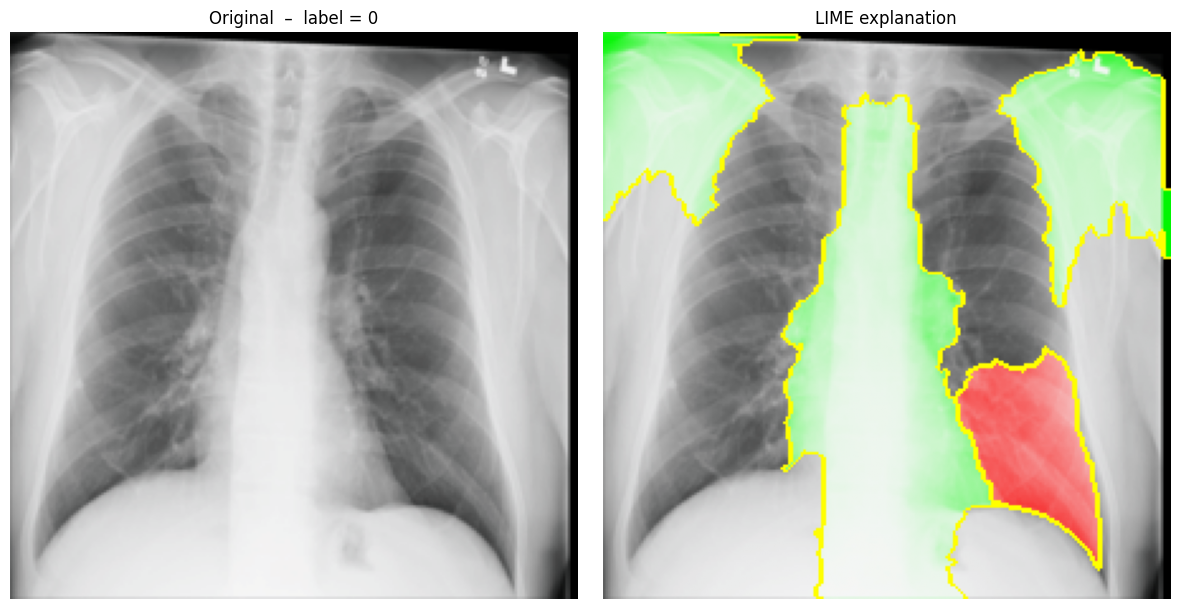

  0%|          | 0/1000 [00:00<?, ?it/s]

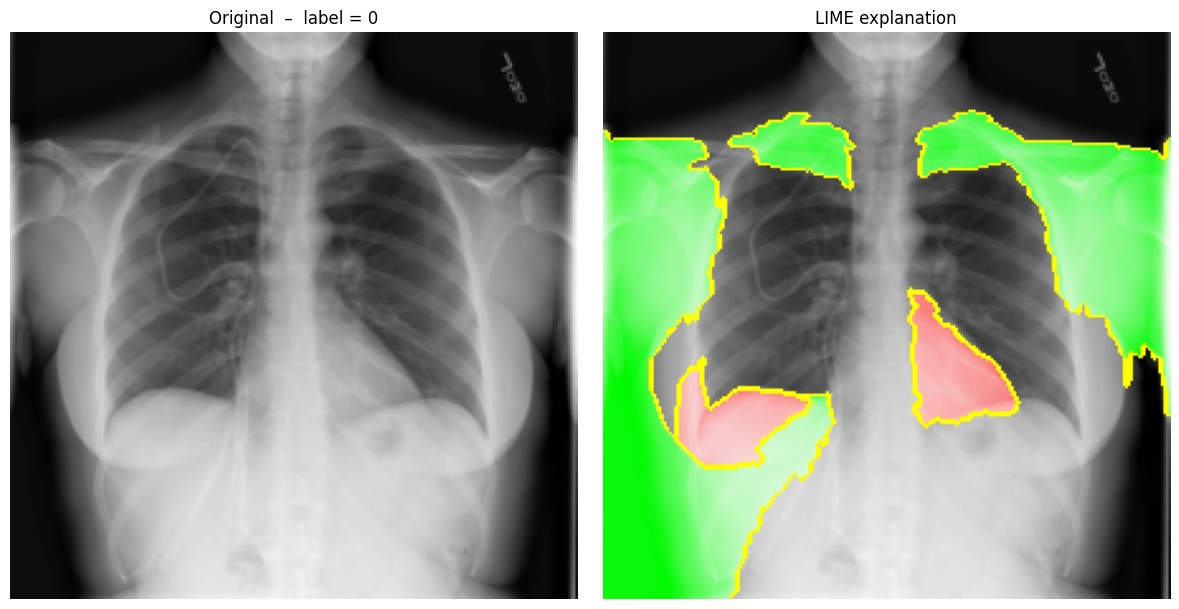

  0%|          | 0/1000 [00:00<?, ?it/s]

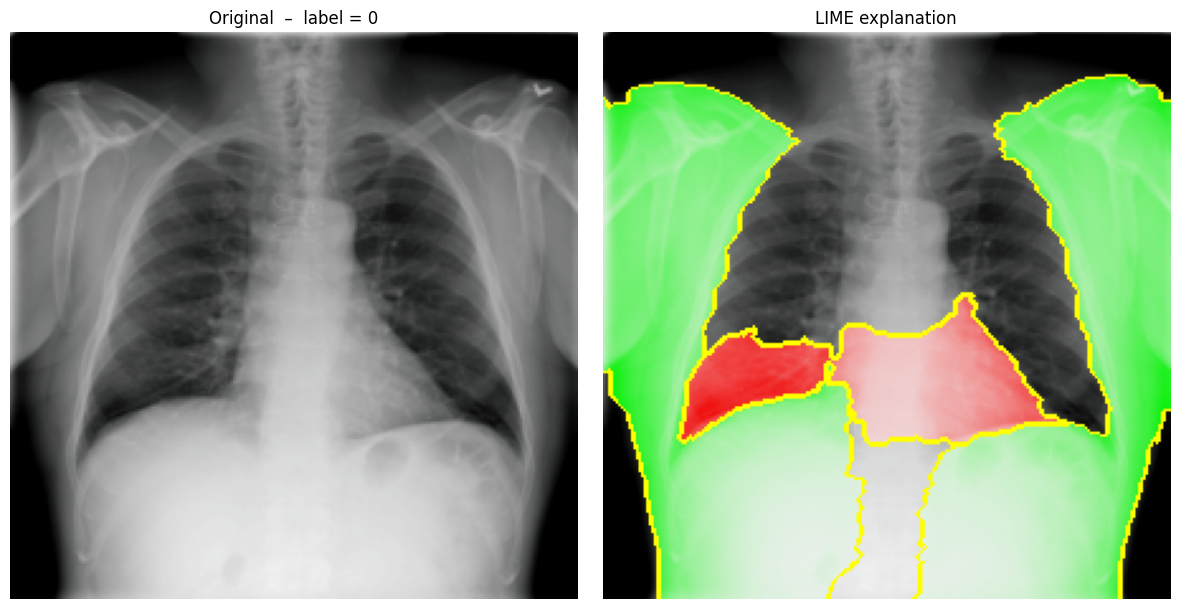

  0%|          | 0/1000 [00:00<?, ?it/s]

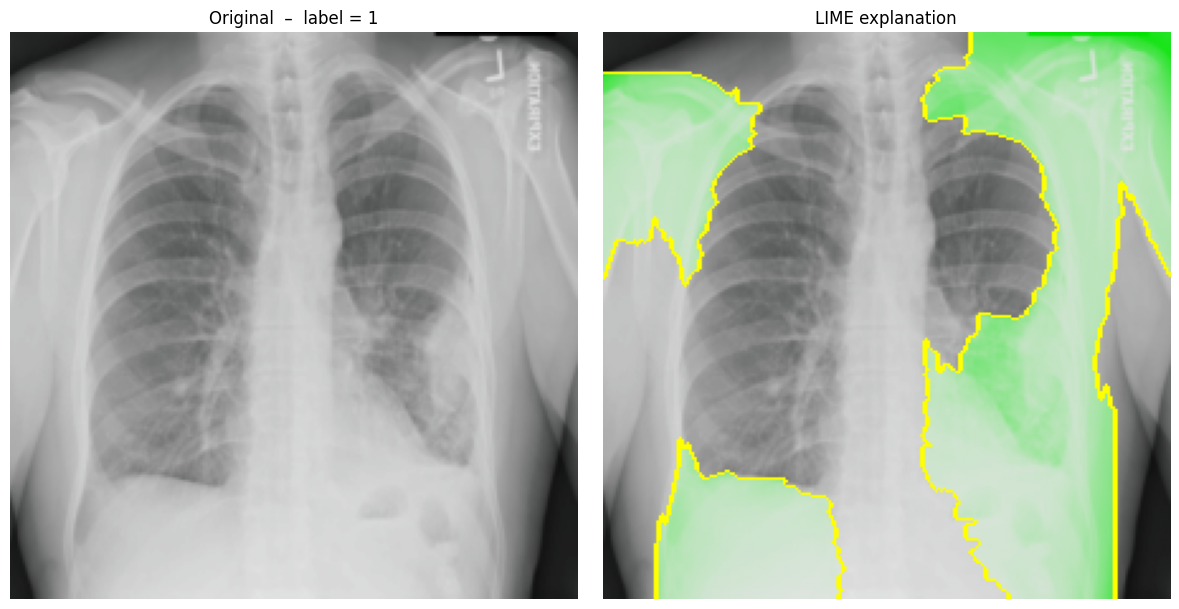

  0%|          | 0/1000 [00:00<?, ?it/s]

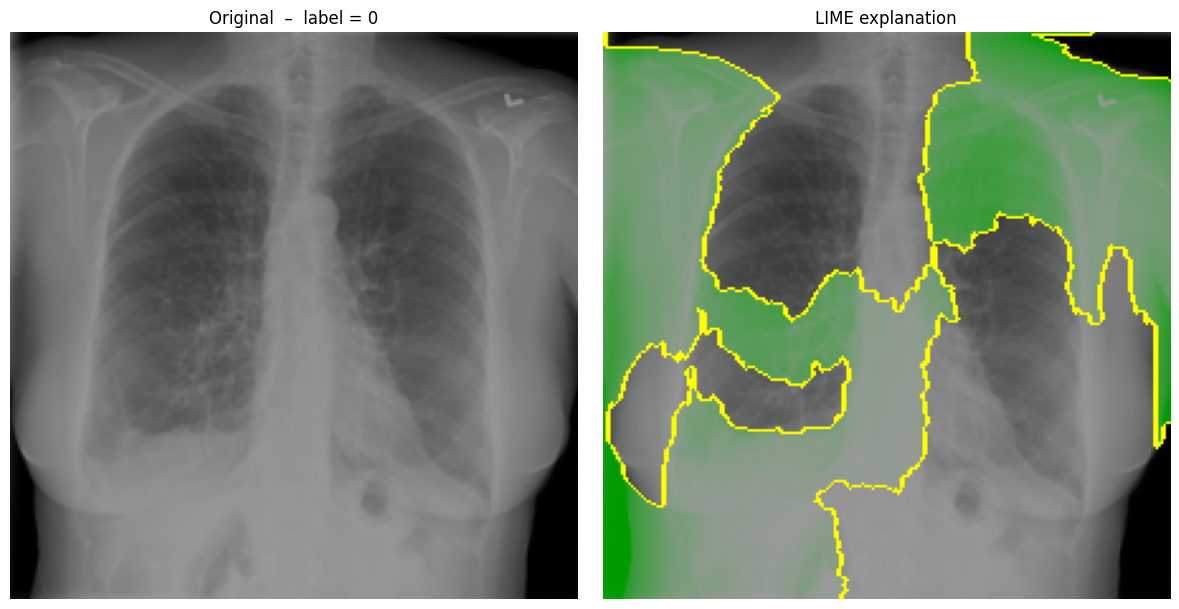

In [ ]:
explainer = lime_image.LimeImageExplainer(random_state=42)

num_samples_to_show = 5      # how many images you want to inspect
lime_samples        = 1000   # neighbourhood size – higher = slower but smoother
top_labels          = [1]    # we care about the “positive” class (index 1)

for i in range(num_samples_to_show):
    img_tensor, true_label = test_ds[i]
    img_uint8              = tensor_to_uint8(img_tensor)

    # LIME explanation
    explanation = explainer.explain_instance(
        image=img_uint8,
        classifier_fn=batch_predict,
        labels=top_labels,
        hide_color=0,
        num_samples=lime_samples
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=1,
        positive_only=False,
        hide_rest=False,
        num_features=8,
        min_weight=0.0
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.imshow(img_uint8)
    ax1.set_title(f"Original  –  label = {int(true_label)}")
    ax1.axis("off")

    ax2.imshow(mark_boundaries(lime_img / 255.0, lime_mask))
    ax2.set_title("LIME explanation")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<b>Q3.</b> In what case do you find usefull the boundaries from the LIME created the <code>LIME</code> explainer. Can you spot the lesions in the image under the predicted class activation maps? Can you see challenging examples?